In [5]:
import pandas as pd

# Cargar archivo base
df = pd.read_csv('../data/processed/turismo_combinado_2025_2026.csv')

# Seleccionar solo la columna de interés
zonas = df['Zona_Pais'].dropna().unique()

# Opcional: eliminar entradas que sean de clima
zonas = [z for z in zonas if z not in ['temperature_2m_max', 'temperature_2m_min', 'precipitation_sum']]

# Ver resultado
print(f"✅ Se encontraron {len(zonas)} zonas o países:")
for z in zonas:
    print('-', z)

# Si quieres exportarlo
pd.Series(zonas, name='Zona_Pais').to_csv('../data/processed/lista_paises.csv', index=False, encoding='utf-8')
print("\n💾 Archivo creado: ../data/processed/lista_paises.csv")


✅ Se encontraron 83 zonas o países:
- TOTAL
- AMERICA DEL NORTE
- CANADA
- ESTADOS UNIDOS
- MEXICO
- AMERICA CENTRAL
- BELICE
- EL SALVADOR
- GUATEMALA
- HONDURAS
- NICARAGUA
- PANAMA
- AMÉRICA DEL SUR
- ARGENTINA
- BOLIVIA
- BRASIL
- CHILE
- COLOMBIA
- ECUADOR
- GUYANA
- GUYANA FRANCESA
- PARAGUAY
- PERU
- SURINAM
- URUGUAY
- VENEZUELA
- CARIBE
- BAHAMAS
- BERMUDA
- CUBA
- HAITÍ
- JAMAICA
- PUERTO RICO
- REPÚBLICA DOMINICANA
- TRINIDAD Y TOBAGO
- OTROS CARIBE
- EUROPA
- ALEMANIA
- AUSTRIA
- BELGICA
- DINAMARCA
- ESLOVAQUIA
- ESPAÑA
- FINLANDIA
- FRANCIA
- HUNGRIA
- IRLANDA
- ISRAEL
- ITALIA
- NORUEGA
- PAISES BAJOS
- POLONIA
- PORTUGAL
- REINO UNIDO
- REPUBLICA CHECA
- RUMANIA
- RUSIA
- SUECIA
- SUIZA
- OTROS EUROPA
- ASIA Y EL PACIFICO
- CHINA
- FILIPINAS
- INDIA
- JAPON
- REP. DE COREA (SUR)
- REP. DEM. POP. DE COREA (NORTE)
- TAIWAN
- AUSTRALIA
- NUEVA ZELANDA
- OTROS ASIA Y EL PACIFICO
- ÁFRICA
- MARRUECOS
- NIGERIA
- SUDAFRICA
- OTROS ÁFRICA
- ORIENTE MEDIO
- ARABIA SAUDITA
- EGI

In [6]:
import pandas as pd

df_paises = pd.read_csv('../data/processed/lista_paises.csv')

# Valores a excluir (no son países reales)
excluir = [
    'TOTAL', 'AMERICA DEL NORTE', 'AMERICA CENTRAL', 'AMÉRICA DEL SUR',
    'CARIBE', 'EUROPA', 'ASIA Y EL PACIFICO', 'ÁFRICA', 'ORIENTE MEDIO',
    'OTROS CARIBE', 'OTROS EUROPA', 'OTROS ASIA Y EL PACIFICO',
    'OTROS ÁFRICA', 'OTROS ORIENTE MEDIO'
]

# Estandarizar letras codificadas mal por problemas de encoding
df_paises['Zona_Pais'] = (df_paises['Zona_Pais']
                          .str.encode('latin1', 'ignore')
                          .str.decode('utf-8', 'ignore')
                          .str.strip())

# Aplicar exclusión
df_paises = df_paises[~df_paises['Zona_Pais'].isin(excluir)].reset_index(drop=True)

print(f"✅ Países reales detectados: {len(df_paises)}")
df_paises.head(15)


✅ Países reales detectados: 72


,Zona_Pais
0,CANADA
1,ESTADOS UNIDOS
2,MEXICO
3,BELICE
4,EL SALVADOR
5,GUATEMALA
6,HONDURAS
7,NICARAGUA
8,PANAMA
9,AMRICA DEL SUR


In [8]:
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="turismoCR")

coords = []
for pais in df_paises['Zona_Pais']:
    try:
        location = geolocator.geocode(pais)
        if location:
            coords.append({
                'Zona_Pais': pais,
                'Lat': location.latitude,
                'Lon': location.longitude
            })
        else:
            coords.append({'Zona_Pais': pais, 'Lat': None, 'Lon': None})
    except Exception as e:
        coords.append({'Zona_Pais': pais, 'Lat': None, 'Lon': None})
    time.sleep(1)  # para no saturar el servidor

df_coords = pd.DataFrame(coords)
print(f"✅ Coordenadas obtenidas para {df_coords['Lat'].notna().sum()} países")
df_coords.head()


✅ Coordenadas obtenidas para 67 países


,Zona_Pais,Lat,Lon
0,CANADA,61.066692,-107.991707
1,ESTADOS UNIDOS,39.783730,-100.445882
2,MEXICO,23.658512,-102.007710
3,BELICE,17.120494,-88.685903
4,EL SALVADOR,13.800038,-88.914068


In [9]:
# Cargar base de turismo 2025–2026
df_turismo = pd.read_csv('../data/processed/turismo_combinado_2025_2026.csv')

# Filtrar filas de turismo (no clima)
df_turismo = df_turismo[~df_turismo['Zona_Pais'].isin(
    ['temperature_2m_max','temperature_2m_min','precipitation_sum']
)]

# Reestructurar meses como filas y limpiar formato
df_long = df_turismo.melt(id_vars='Zona_Pais', var_name='Mes', value_name='Turistas')
df_long['Mes'] = df_long['Mes'].str.replace('_','-')
df_long = df_long[df_long['Mes'].str.match(r'^\d{2}-\d{4}$', na=False)]

# Calcular total o promedio por país
df_resumen = df_long.groupby('Zona_Pais')['Turistas'].mean().reset_index()
df_resumen.rename(columns={'Turistas':'Turistas_promedio'}, inplace=True)

# Unir con coordenadas
df_geo_final = df_resumen.merge(df_coords, on='Zona_Pais', how='inner')

# Exportar resultado final
output_path = '../data/processed/turismo_origen_geolocalizado_2025_2026.csv'
df_geo_final.to_csv(output_path, index=False, encoding='utf-8')
print(f"💾 Archivo creado: {output_path}")
df_geo_final.head()


💾 Archivo creado: ../data/processed/turismo_origen_geolocalizado_2025_2026.csv


,Zona_Pais,Turistas_promedio,Lat,Lon
0,ALEMANIA,7371.571429,51.163818,10.447831
1,ARABIA SAUDITA,23.071429,25.624262,42.352833
2,ARGENTINA,3329.428571,-34.996496,-64.967282
3,AUSTRALIA,794.214286,-24.776109,134.755000
4,AUSTRIA,796.357143,47.593970,14.124560


In [10]:
from visualizacion.visualizador_mapas import VisualizadorMapas

vis = VisualizadorMapas()
df_geo = pd.read_csv('../data/processed/turismo_origen_geolocalizado_2025_2026.csv')

mapa_flujo = vis.mapa_flujo(df_geo, valor_col='Turistas_promedio')
mapa_flujo.save('../notebooks/mapa_flujo_turismo_2025_2026.html')
mapa_flujo


In [11]:
import pandas as pd
from visualizacion.visualizador_mapas import VisualizadorMapas

# Cargar dataset geolocalizado
df_geo = pd.read_csv('../data/processed/turismo_origen_geolocalizado_2025_2026.csv')

# Crear el visualizador
vis_mapas = VisualizadorMapas()

# Mapa interactivo
mapa_int = vis_mapas.mapa_interactivo(df_geo,
                                      lat_col='Lat',
                                      lon_col='Lon',
                                      valor_col='Turistas_promedio',
                                      color='purple')

mapa_int.save('../notebooks/mapa_interactivo_turistas_origen.html')
mapa_int


In [13]:
top10 = df_geo.sort_values('Turistas_promedio', ascending=False).head(10)
print(top10)


         Zona_Pais  Turistas_promedio        Lat         Lon
22  ESTADOS UNIDOS      138239.785714  39.783730 -100.445882
11          CANADA       25454.571429  61.066692 -107.991707
41       NICARAGUA        8278.357143  12.350644  -85.784101
40          MEXICO        7881.571429  23.658512 -102.007710
0         ALEMANIA        7371.571429  51.163818   10.447831
25         FRANCIA        6621.857143  46.603354    1.888334
52     REINO UNIDO        6278.714286  54.702354   -3.276575
46          PANAMA        4053.214286   8.559559  -81.130843
26       GUATEMALA        3767.785714  15.585555  -90.345759
2        ARGENTINA        3329.428571 -34.996496  -64.967282


C:\Users\maortiz\AppData\Local\Temp\ipykernel_9404\2964239937.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, y='Zona_Pais', x='Turistas_promedio', palette='viridis')


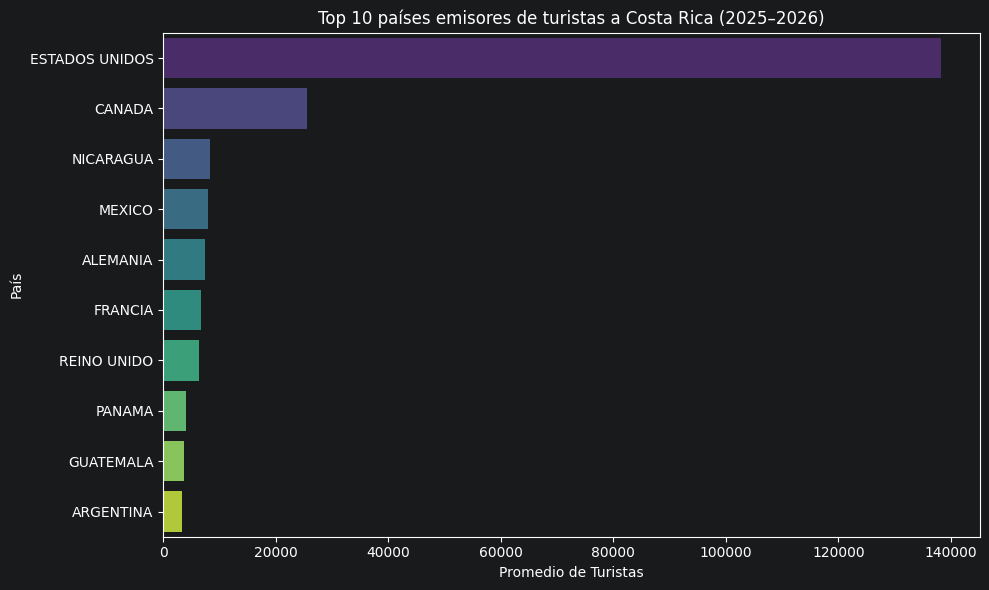

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=top10, y='Zona_Pais', x='Turistas_promedio', palette='viridis')
plt.title('Top 10 países emisores de turistas a Costa Rica (2025–2026)')
plt.xlabel('Promedio de Turistas')
plt.ylabel('País')
plt.tight_layout()
plt.show()


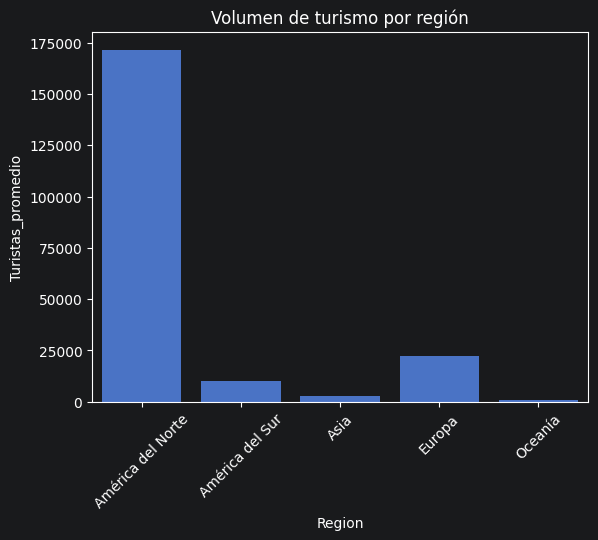

In [16]:
# ejemplo: crear columna manualmente si no existe
regiones = {
    'CANADA':'América del Norte', 'ESTADOS UNIDOS':'América del Norte', 'MEXICO':'América del Norte',
    'ARGENTINA':'América del Sur', 'CHILE':'América del Sur', 'COLOMBIA':'América del Sur', 'BRASIL':'América del Sur',
    'ESPAÑA':'Europa', 'ALEMANIA':'Europa', 'FRANCIA':'Europa', 'ITALIA':'Europa', 'REINO UNIDO':'Europa',
    'CHINA':'Asia', 'JAPON':'Asia', 'INDIA':'Asia', 'AUSTRALIA':'Oceanía'
}
df_geo['Region'] = df_geo['Zona_Pais'].map(regiones)
df_regiones = df_geo.groupby('Region')['Turistas_promedio'].sum().reset_index()

sns.barplot(df_regiones, x='Region', y='Turistas_promedio')
plt.title('Volumen de turismo por región')
plt.xticks(rotation=45)
plt.show()
